# HW2, revised solution to Problem 3

In [89]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import norm
np.random.seed(42)

### this is the provided dataset to fit:

In [90]:
x = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
y = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [92]:
Ndata = len(yErr)

# this is old method, 
## which becomes numerically unstable for high polynomial orders...

In [118]:
from scipy import stats
from scipy import optimize

# this function computes polynomial models given some data x
# and parameters theta
def polynomial_fit(theta, x):
    """Polynomial model of degree (len(theta) - 1)"""
    return sum(t * x ** n for (n, t) in enumerate(theta))

# compute the data log-likelihood given a model
def logL(theta, x, y, sigma_y, model=polynomial_fit):
    """Gaussian log-likelihood of the model at theta"""
    y_fit = model(theta, x)
    return np.sum(stats.norm.logpdf(y, y_fit, sigma_y))

# a direct optimization approach is used to get best model 
# parameters (which minimize -logL)
def best_theta(degree, x, y, sigma_y, model=polynomial_fit):
    
    # prior
    theta_0 = (degree + 1) * [0] 
    # negative log likelihood     
    neg_logL = lambda theta: -logL(theta, x, y, sigma_y, model)
    return optimize.fmin_bfgs(neg_logL, theta_0, disp=False)

In [123]:
def plotOldBestFit(x, y, yErr, Npoly):
    sigma_y = yErr
    # get best-fit parameters  
    theta_best = best_theta(Npoly, x, y, yErr)
    
    # fit for data points
    yModel = polynomial_fit(theta_best, x)

    # generate best fit lines on a fine grid 
    xfit = np.linspace(-0.2, 5.2, 1000)
    yfit = polynomial_fit(theta_best, xfit)
   
    # plot 
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.errorbar(x, y, yErr, fmt='ok', ecolor='gray')
    ax.plot(xfit, yfit, label='best model')
 

    ax.legend(loc='best', fontsize=14)
    ax.set(xlabel='x', ylabel='y', title='data');
    
    chi2 = np.sum(((y-yModel)/yErr)**2)   
    print('chi2:', chi2)

chi2: 103.01503547251949


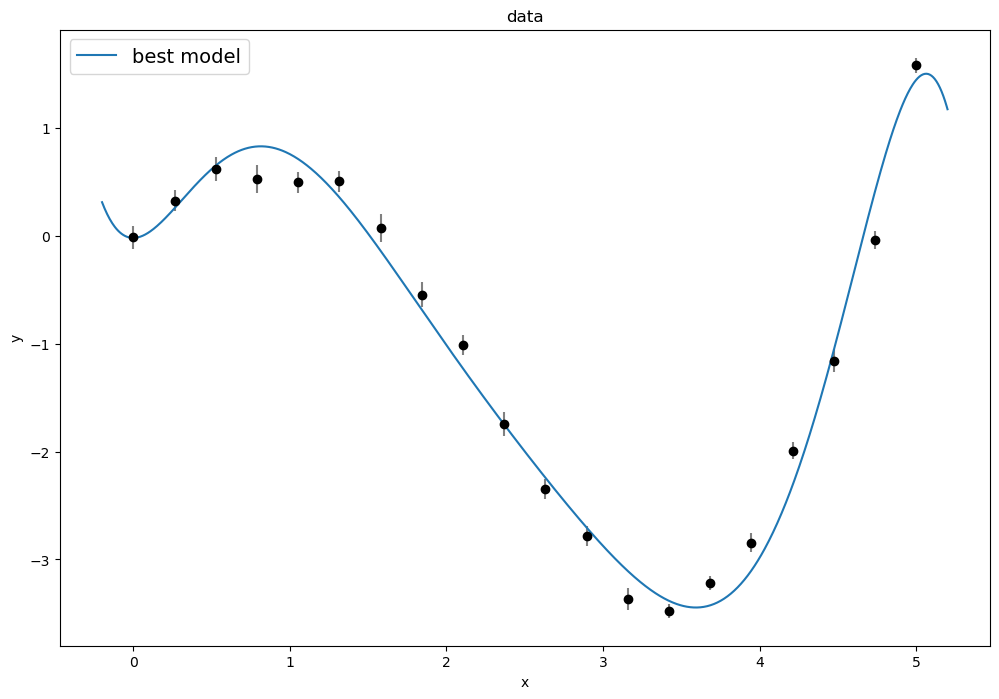

In [128]:
# Npoly=7 kinda works...
plotOldBestFit(x, y, yErr, Npoly=7)

chi2: 5917.581825884574


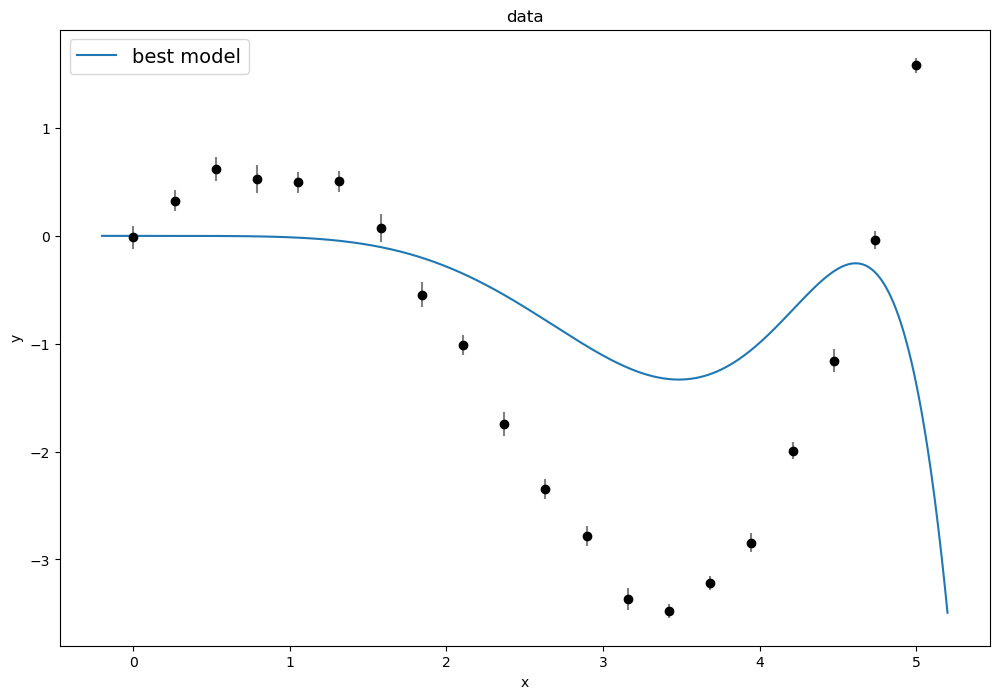

In [129]:
# but Npoly=8 fails miserably: 
plotOldBestFit(x, y, yErr, Npoly=8)

## a revised method, which scales the x range, and uses Chebyshev polynomials: 

In [130]:
from numpy.polynomial.chebyshev import chebvander

# ----------------------------------------------------------------------
# stable polynomial model using Chebyshev basis
# this is the ** main change ** compared to the code above
def polynomial_fit(theta, x):
    """
    Polynomial model using Chebyshev polynomials.
    """
    degree = len(theta) - 1

    # build Chebyshev Vandermonde matrix
    V = chebvander(x, degree)

    return V @ theta


# ----------------------------------------------------------------------
# Gaussian log-likelihood
def logL(theta, x, y, sigma_y, model=polynomial_fit):
    y_fit = model(theta, x)
    return np.sum(stats.norm.logpdf(y, loc=y_fit, scale=sigma_y))


# ----------------------------------------------------------------------
# optimization
def best_theta(degree, x, y, sigma_y, model=polynomial_fit):

    # scale x first
    x_scaled = scale_x(x)

    # initial guess
    theta_0 = np.zeros(degree + 1)

    # negative log likelihood
    neg_logL = lambda theta: -logL(
        theta,
        x_scaled,
        y,
        sigma_y,
        model
    )

    result = optimize.fmin_bfgs(
        neg_logL,
        theta_0,
        disp=False
    )

    return result

# ----------------------------------------------------------------------
# scale x to [-1, 1]
def scale_x(x):
    xmin = np.min(x)
    xmax = np.max(x)
    return 2 * (x - xmin) / (xmax - xmin) - 1

In [131]:
def plotBestFit(x, y, yErr, Npoly):
    sigma_y = yErr
    # get best-fit parameters  
    theta_best = best_theta(Npoly, x, y, yErr)
    
    # fit for data points
    xsc = scale_x(x)
    yModel = polynomial_fit(theta_best, xsc)

    # generate best fit lines on a fine grid 
    xfit = np.linspace(-0.2, 5.2, 1000)
    x_scaled = scale_x(xfit)
    yfit = polynomial_fit(theta_best, x_scaled)
   
    # plot 
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.errorbar(x, y, yErr, fmt='ok', ecolor='gray')
    ax.plot(xfit, yfit, label='best model')
 

    ax.legend(loc='best', fontsize=14)
    ax.set(xlabel='x', ylabel='y', title='data');
    
    chi2 = np.sum(((y-yModel)/yErr)**2)   
    print('chi2:', chi2)

chi2: 11.2747489652037


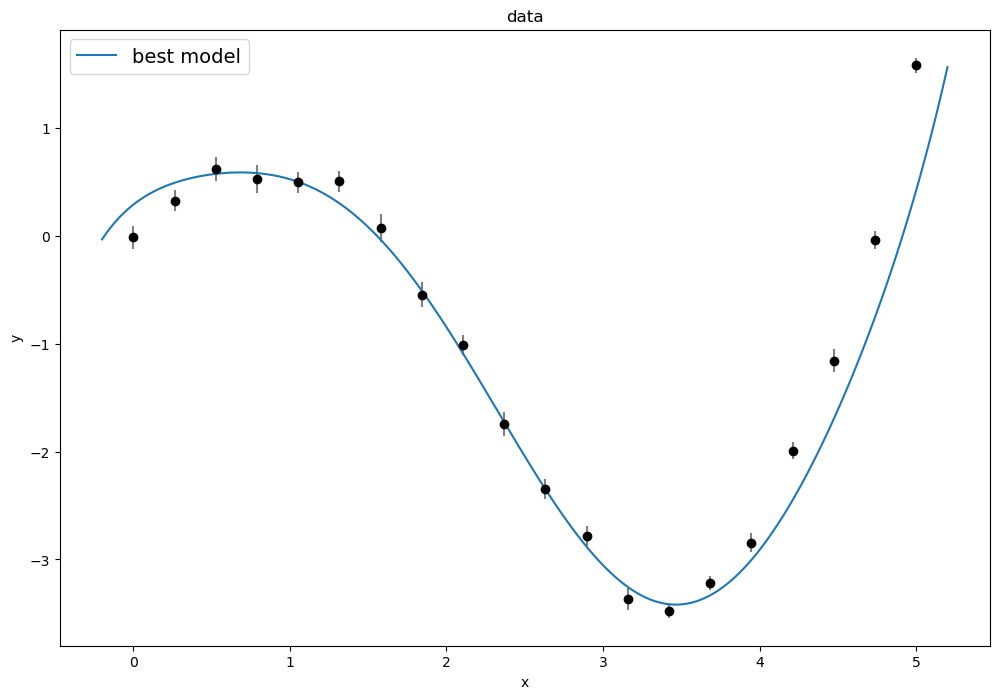

In [132]:
plotBestFit(x, y, yErr, Npoly=7)

chi2: 9.649109020562003


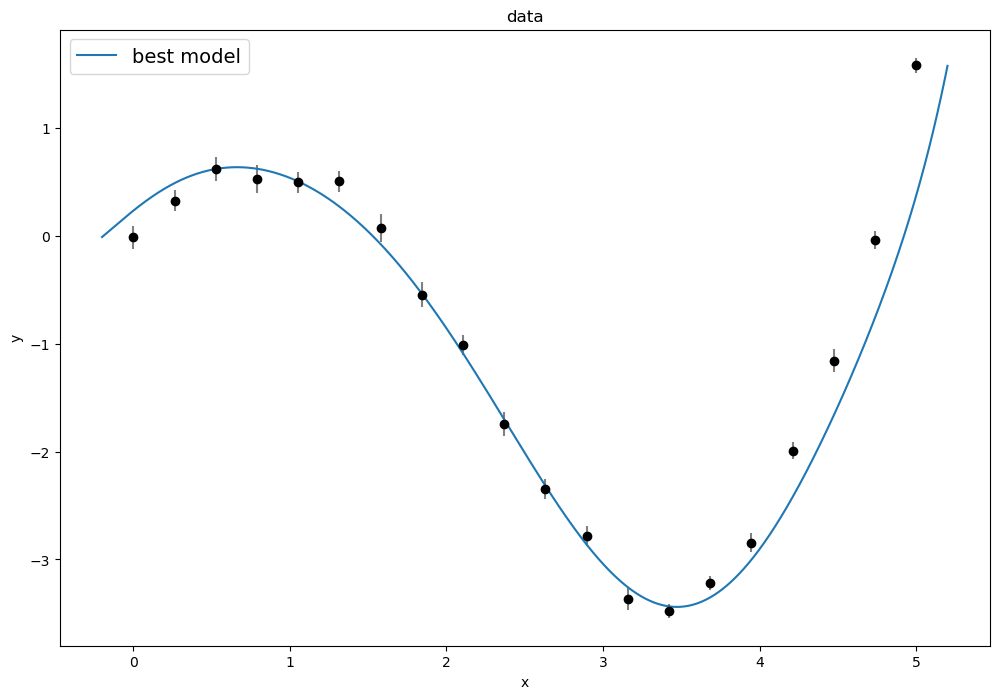

In [133]:
plotBestFit(x, y, yErr, Npoly=8)

chi2: 8.58598905863165


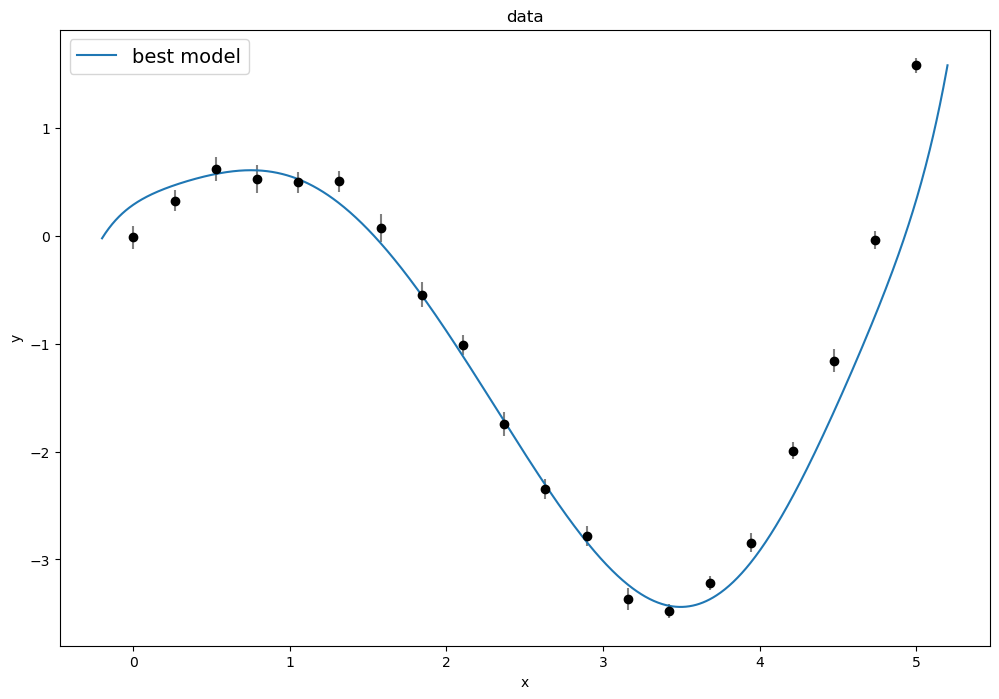

In [134]:
plotBestFit(x, y, yErr, Npoly=9)

chi2: 8.584886524005784


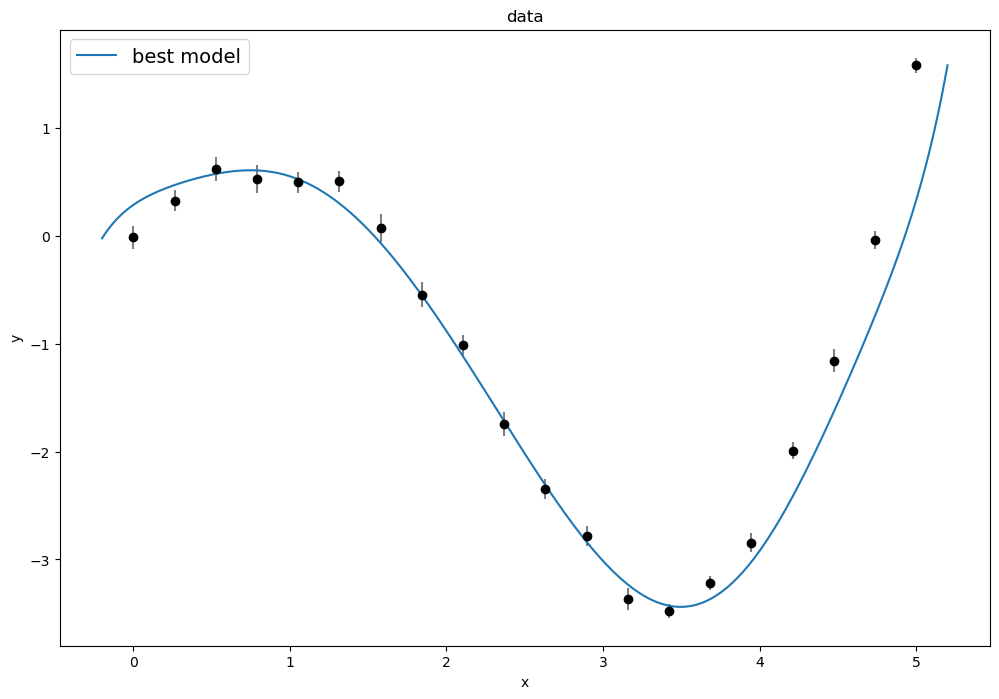

In [135]:
plotBestFit(x, y, yErr, Npoly=10)

In [136]:
theta = []
chi2 = []
Bpenalty = []
BIC= []
xsc = scale_x(x)
for i in range(0,11):
    theta.append(best_theta(i, x, y, yErr))
    chi2.append(np.sum(((y-polynomial_fit(theta[i], xsc))/yErr)**2))
    Bpenalty.append((i+1)*np.log(Ndata))
    BIC.append(chi2[i] + Bpenalty[i])

In [142]:
print("poly order           chi2             penalty           BIC")
for i in range(0,11):
    print('   ', i, '       ', chi2[i], ' ', Bpenalty[i], '  ', BIC[i]) 

poly order           chi2             penalty           BIC
    0         6911.286836351887   2.995732273553991    6914.282568625441
    1         6384.903159375279   5.991464547107982    6390.894623922387
    2         2792.917232559525   8.987196820661973    2801.904429380187
    3         63.35225020884866   11.982929094215963    75.33517930306462
    4         62.43666572302285   14.978661367769954    77.4153270907928
    5         18.707636498400053   17.974393641323946    36.682030139724
    6         18.63218825253796   20.970125914877936    39.6023141674159
    7         11.2747489652037   23.965858188431927    35.24060715363563
    8         9.649109020562003   26.961590461985917    36.61069948254792
    9         8.58598905863165   29.957322735539908    38.54331179417156
    10         8.584886524005784   32.9530550090939    41.53794153309968
